# Phase 1 Final Exam 🎓
### by KayCee - 9th May, 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

## Task 1 — Data & Returns

#### 1.1 - **Generate Price Data**

In [2]:
np.random.seed(42)
returns = np.random.normal(0.0005, 0.008, 500)
close_prices = np.round(4715.715 * (1 + returns).cumprod(), 2)

df = pd.DataFrame({
    'Close': close_prices
}, index= pd.date_range(start='2025-01-01', periods=500, freq='B'))

In [3]:
df.head(2)

,Close
2025-01-01,4736.81
2025-01-02,4733.94


#### 1.2 - **Calculate daily log returns**

In [4]:
df['log_return'] = np.log(df['Close']/df['Close'].shift(1))

df.head(2)

,Close,log_return
2025-01-01,4736.81,NaN
2025-01-02,4733.94,-0.000606


#### 1.3 - **Calculate GBM parameters (muhat & sigmahat)**

In [5]:
delta = 1/255 # daily 
muhat = (df['log_return'].mean()/delta) + (df['log_return'].std()**2)/(2*delta)
sigmahat = (df['log_return'].std()) / (delta**0.5) 

print(f'muhat: {muhat:.4f}')
print(f'sigmahat: {sigmahat:.4f}')

muhat: 0.1394
sigmahat: 0.1253


## Task 2 - EMA Strategy

#### 2.1 - **Calculate EMA 20 and EMA 50**

In [6]:
df['EMA_20'] = df['Close'].ewm(span=20,adjust=False).mean()
df['EMA_50'] = df['Close'].ewm(span=50,adjust=False).mean()

df.head(2)

,Close,log_return,EMA_20,EMA_50
2025-01-01,4736.81,NaN,4736.810000,4736.810000
2025-01-02,4733.94,-0.000606,4736.536667,4736.697451


#### 2.2 - **Generate buy/sell signals**

In [7]:
# buy=1 and sell=-1
df['Signal'] = np.where(df['EMA_20']>df['EMA_50'],
                       1,-1)

df.head(3)

,Close,log_return,EMA_20,EMA_50,Signal
2025-01-01,4736.81,NaN,4736.810000,4736.810000,-1
2025-01-02,4733.94,-0.000606,4736.536667,4736.697451,-1
2025-01-03,4760.84,0.005666,4738.851270,4737.644218,1


#### 2.3 - **Plot the EMA Crossover**

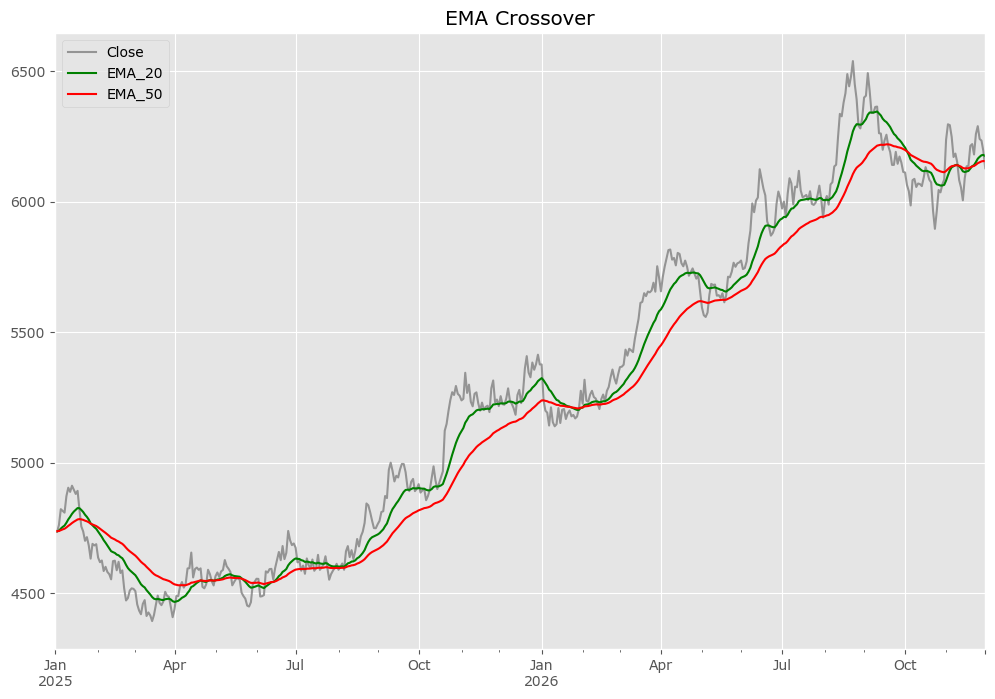

In [8]:
plt.figure(figsize=(12,8))

df['Close'].plot(color='grey',alpha=0.8)
df['EMA_20'].plot(color='green')
df['EMA_50'].plot(color='red')

plt.title('EMA Crossover')
plt.legend()
plt.show()

## Task 3 - Risk Metrics

#### 3.1 - **Calculate Sys Return & Cumulative Return**

In [9]:
df['return'] = df['Close'].pct_change() # simple return
df['Sys_return'] = df['return'] * df['Signal'].shift(1)

df['Cum_return'] = (1+ df['Sys_return']).cumprod()

df.head(2)

,Close,log_return,EMA_20,EMA_50,Signal,return,Sys_return,Cum_return
2025-01-01,4736.81,NaN,4736.810000,4736.810000,-1,NaN,NaN,NaN
2025-01-02,4733.94,-0.000606,4736.536667,4736.697451,-1,-0.000606,0.000606,1.000606


#### 3.2 - **Max Drawdown**

In [10]:
df['Rolling_max'] = df['Cum_return'].cummax()

df['Drawdown'] = (df['Cum_return'] - df['Rolling_max']) / df['Rolling_max']
Max_dd = df['Drawdown'].min()

#Max_dd = ((df['Cum_return'] - df['Rolling_max']) / df['Rolling_max']).min()

print(f'The Maximum Drawdown for this strategy is {Max_dd:.2%}')

The Maximum Drawdown for this strategy is -14.74%


#### 3.3 - **Max Run-up**

In [11]:
df['Rolling_min'] = df['Cum_return'].cummin()

df['Runup'] = (df['Cum_return'] - df['Rolling_min']) / df['Rolling_min']
Max_runup = df['Runup'].max()

#Max_runup = ((df['Cum_return'] - df['Rolling_min']) / df['Rolling_min']).max()

print(f'The Maximum Runup for this strategy is {Max_runup:.2%}')

The Maximum Runup for this strategy is 36.11%


#### 3.4 - **Total Return**

In [12]:
total_return = df['Cum_return'].iloc[-1] - 1

print(f'Total Return: {total_return:.4f}')

Total Return: 0.0516


#### 3.5 - **Sharpe Ratio**

In [13]:
Sharpe_ratio = df['Sys_return'].mean()/df['Sys_return'].std()

print(f'Sharpe Ratio: {Sharpe_ratio:.4f}')

Sharpe Ratio: 0.0167


## Task 4 - Report Card

#### 4.1 - **Print clean formatted report card**

In [14]:
print('='*35)
print('   XAUUSD EMA CROSSOVER — REPORT CARD')
print('='*35)
print(f'muhat: {muhat:.4f}')
print(f'sigmahat: {sigmahat:.4f}')
print(f'Daily Volatility: {df["log_return"].std():.4f}')
print(f'Total Return: {total_return:.4f}')
print(f'Sharpe Ratio: {Sharpe_ratio:.4f}')
print(f'Maximum Drawdown for this strategy: {Max_dd:.2%}')
print(f'Maximum Runup for this strategy is {Max_runup:.2%}')

   XAUUSD EMA CROSSOVER — REPORT CARD
muhat: 0.1394
sigmahat: 0.1253
Daily Volatility: 0.0078
Total Return: 0.0516
Sharpe Ratio: 0.0167
Maximum Drawdown for this strategy: -14.74%
Maximum Runup for this strategy is 36.11%


#### 4.1 - **Add your own interpretation of each metric**

In [15]:
print(f'Sharpe > 1.0 is good. Mine: {Sharpe_ratio:.2f}')
print(f'Max DD < 20% is safe. Mine: {Max_dd:.2%}')

Sharpe > 1.0 is good. Mine: 0.02
Max DD < 20% is safe. Mine: -14.74%


## Task 5 - Visualization

#### 5.1 - **Plot Drawdown over time**

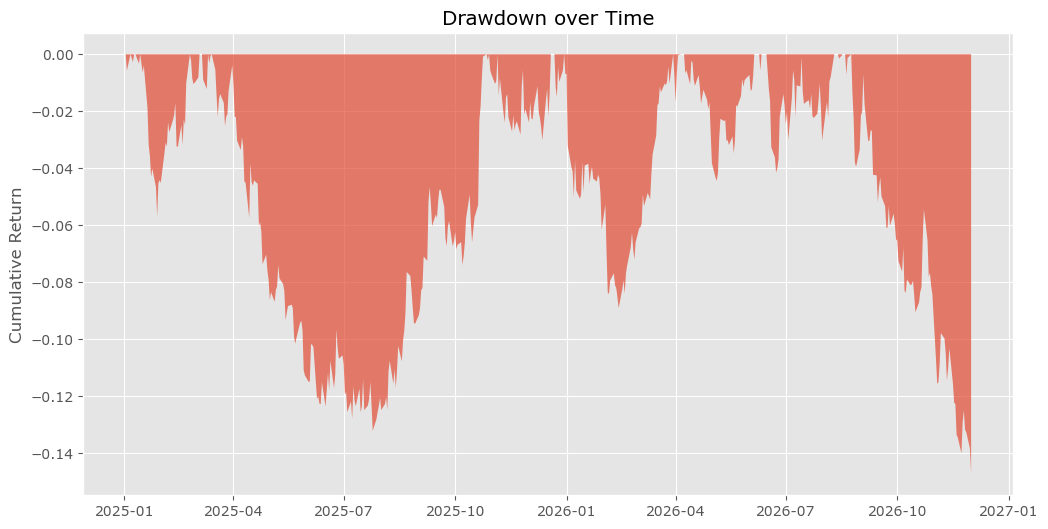

In [16]:
plt.figure(figsize=(12,6))
plt.fill_between(df.index,df['Drawdown'],
                alpha=0.7)

plt.ylabel('Cumulative Return')
plt.title('Drawdown over Time')
plt.show()

#### 5.1 - **Plot Run-up over time**

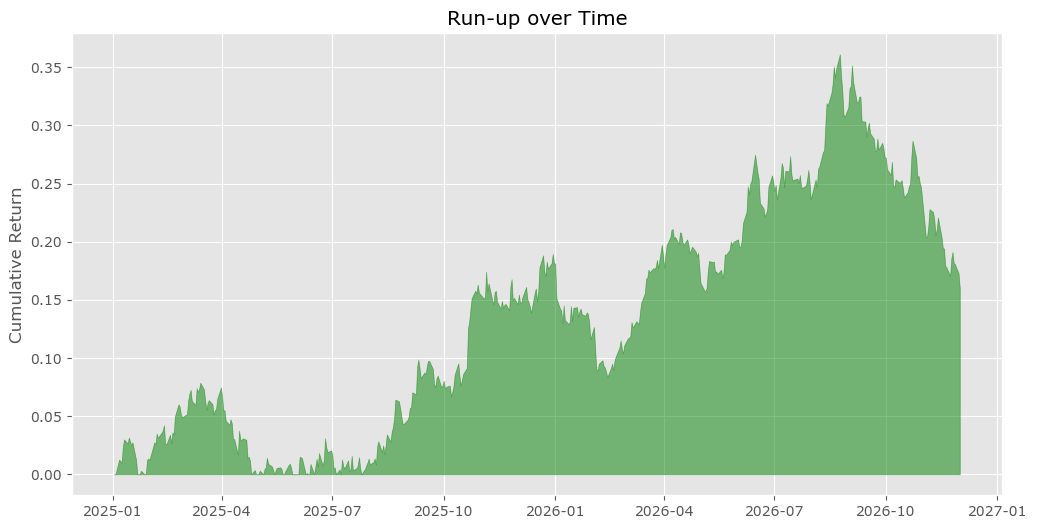

In [17]:
plt.figure(figsize=(12,6))
plt.fill_between(df.index,df['Runup'],
                 color='green',alpha=0.5)

plt.ylabel('Cumulative Return')
plt.title('Run-up over Time')
plt.show()